In [1]:
print(5)

5


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from PIL import Image

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [3]:
BASE_DIR = Path.cwd().parent

MODEL_PATH = BASE_DIR / "models" / "mobilenetv2_finetuned.h5"
TEST_DIR = BASE_DIR / "data" / "test"

print("Model exists:", MODEL_PATH.exists())
print("Test directory exists:", TEST_DIR.exists())

Model exists: True
Test directory exists: True


In [4]:
# Defining class labels

class_labels = [
    "animal fish",
    "animal fish bass",
    "fish sea_food black_sea_sprat",
    "fish sea_food gilt_head_bream",
    "fish sea_food hourse_mackerel",
    "fish sea_food red_mullet",
    "fish sea_food red_sea_bream",
    "fish sea_food sea_bass",
    "fish sea_food shrimp",
    "fish sea_food striped_red_mullet",
    "fish sea_food trout"
]

In [5]:
# Loading the best model

best_model = load_model(MODEL_PATH)

In [6]:
# Prediction

def predict_fish_image(img_path, model, class_labels, top_k=3):
    img = image.load_img(
        img_path,
        target_size=(224, 224)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array, verbose=0)[0]

    top_indices = predictions.argsort()[-top_k:][::-1]

    top_predictions = [
        {
            "class": class_labels[i],
            "confidence": float(predictions[i])
        }
        for i in top_indices
    ]

    return img, top_predictions

In [12]:
# Manually selecting one image

sample_image_path = TEST_DIR / "fish sea_food hourse_mackerel" / "0B4M483HD8NM.jpg"

sample_class_dir = TEST_DIR / "fish sea_food hourse_mackerel"

list(sample_class_dir.iterdir())[:5]

[WindowsPath('e:/Guvi/Projects/Assignment 5/fish_image_classification/data/test/fish sea_food hourse_mackerel/00J0L8NCOIR7.jpg'),
 WindowsPath('e:/Guvi/Projects/Assignment 5/fish_image_classification/data/test/fish sea_food hourse_mackerel/015G960G2YZU.jpg'),
 WindowsPath('e:/Guvi/Projects/Assignment 5/fish_image_classification/data/test/fish sea_food hourse_mackerel/06GO7B7BPPDH.jpg'),
 WindowsPath('e:/Guvi/Projects/Assignment 5/fish_image_classification/data/test/fish sea_food hourse_mackerel/09JLKOFF5KD2.jpg'),
 WindowsPath('e:/Guvi/Projects/Assignment 5/fish_image_classification/data/test/fish sea_food hourse_mackerel/0B4M483HD8NM.jpg')]

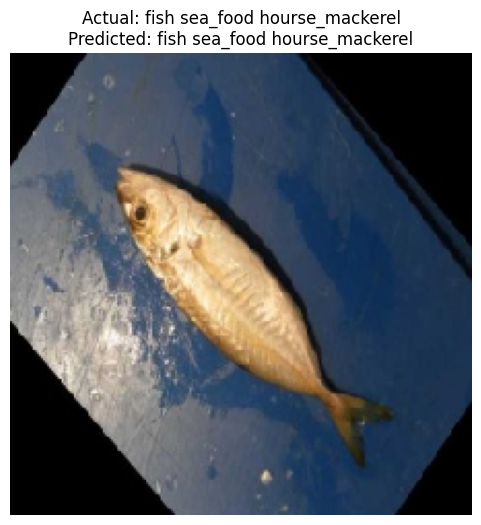

Actual class: fish sea_food hourse_mackerel
Predicted class: fish sea_food hourse_mackerel
Confidence: 99.97%

Top Predictions:
fish sea_food hourse_mackerel: 99.97%
fish sea_food striped_red_mullet: 0.03%
fish sea_food red_sea_bream: 0.00%


In [ ]:
# Run prediction on one image

img, top_predictions = predict_fish_image(
    sample_image_path,
    best_model,
    class_labels
)

actual_class = sample_image_path.parent.name
predicted_class = top_predictions[0]["class"]
confidence = top_predictions[0]["confidence"]

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class}"
)
plt.show()

print("Actual class:", actual_class)
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

print("\nTop Predictions:")
for pred in top_predictions:
    print(f"{pred['class']}: {pred['confidence'] * 100:.2f}%")

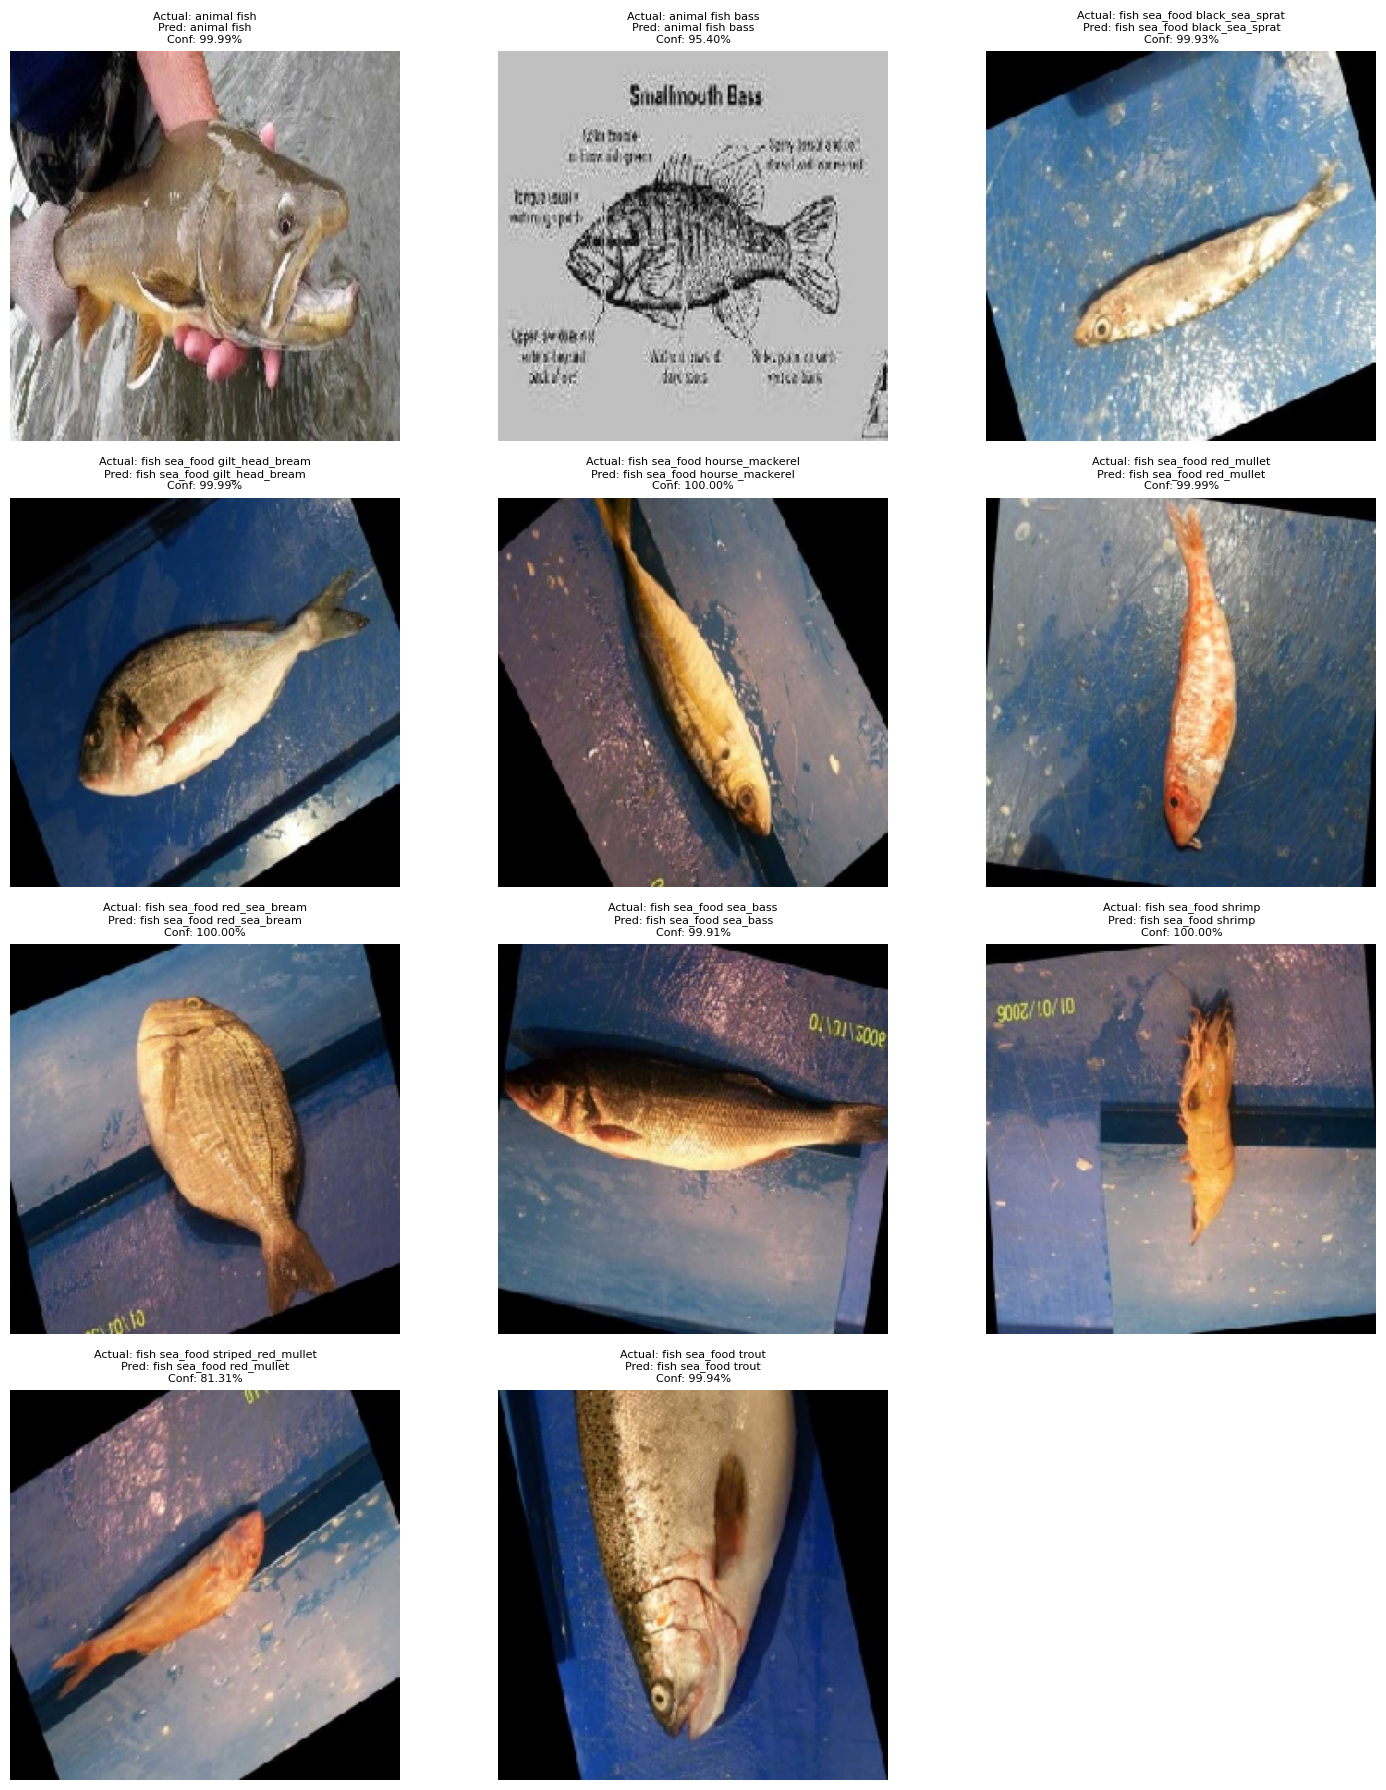

In [ ]:
# Predict a random image from each class

import random

plt.figure(figsize=(15, 18))

for i, class_name in enumerate(class_labels):
    class_dir = TEST_DIR / class_name
    image_files = list(class_dir.iterdir())

    random_image_path = random.choice(image_files)

    img, top_predictions = predict_fish_image(
        random_image_path,
        best_model,
        class_labels,
        top_k=1
    )

    predicted_class = top_predictions[0]["class"]
    confidence = top_predictions[0]["confidence"]

    plt.subplot(4, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Actual: {class_name}\n"
        f"Pred: {predicted_class}\n"
        f"Conf: {confidence * 100:.2f}%",
        fontsize=8
    )

plt.tight_layout()
plt.show()